# Configuration

In [2]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')

from typing import Iterable

In [3]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.variables import *
from core.dgp import MultipleSegmentsTreatmentSelection as MultipleSegments
import core.treatment_selection_multiple_segments as tsms

# DGP

In [27]:
dgp_params = {
    'base_te_arr': np.array([1, 1.1]), 'n_segments': 3,
    'response_type': 'continuous', 'noise_std': 1,
}

dgp = MultipleSegments(**dgp_params)
segment_arr, treatment_arr, outcome_arr = dgp.sample(500, seed=0)
targ_customers = dgp.sample_individuals(100, seed=0)

# Demand Model

In [28]:
emp_te_arr = tsms.estimate_te(segment_arr, treatment_arr, outcome_arr, dgp.n_segments, dgp.n_treatments)

for segment_idx in range(dgp.n_segments):
    for treatment_idx in range(dgp.n_treatments):
        print(f'Segment {segment_idx}, Treatment {treatment_idx}: True TE = {dgp.te_arr[segment_idx, treatment_idx]:.4f}, Estimated TE = {emp_te_arr[segment_idx, treatment_idx]:.4f}')


TypeError: estimate_te() missing 1 required positional argument: 'response_type'

# Optimization

In [8]:
plugin_decision, plugin_val_est = tsms.optimize(emp_te_arr, targ_customers, budgets=[None, 10])
true_plugin_val = tsms.obj_func(targ_customers, dgp.te_arr, plugin_decision)

print(f'Plugin Decision: {plugin_decision}')
print(f'Estimated Targeting Value: {plugin_val_est:.2f}')
print(f'True Targeting Value: {true_plugin_val:.2f}')

print()
print(f"Winner's curse (measured in MPE): {100 * (plugin_val_est - true_plugin_val)/true_plugin_val:.2f}%")

Plugin Decision: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
Estimated Targeting Value: 87.69
True Targeting Value: 93.99

Winner's curse (measured in MPE): -6.70%


# Winner's Curse

In [11]:
operations_params = {'budgets': [None, 30]}

# dgp params
dgp_params = {
    'base_te_arr': np.array([1, 1.1]), 'n_segments': 3,
    'response_type': 'continuous', 'noise_std': 1,
}

# data params
data_params = {'sample_size': 100, 'n_customers': 100}

# experiment params
experiment_params = {'n_experiments': 5000, 'stats': 'mean'}

# estimators
estimators_dict = {} 

result_records = tsms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=False, 
    n_jobs=-1
)

wc_measures_dict = tsms.calculate_winners_curse_measures(
    result_records, estimators_dict, data_params
)

print(f"Average Estimated Targeting Value: {wc_measures_dict['nc_val_est_avg']:.4f} ({wc_measures_dict['nc_val_est_se']:.4f})")
print(f"Average True Targeting Value: {wc_measures_dict['nc_val_true_avg']:.4f} ({wc_measures_dict['nc_val_true_se']:.4f})")
print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")
print(f"Average Winner's Curse Percentage of True Value: {100 * wc_measures_dict['nc_wc_pct_avg']:.2f}% ({100 * wc_measures_dict['nc_wc_pct_se']:.2f}%)")

print(f"\nRMSE={wc_measures_dict['nc_wc_rmse']:.4f}")

Average Estimated Targeting Value: 109.0011 (1.2909)
Average True Targeting Value: 101.1773 (0.1591)
Average Winner's Curse: 7.8238 (1.2992)
Average Winner's Curse Percentage of True Value: 7.76% (1.29%)

RMSE=15.1660


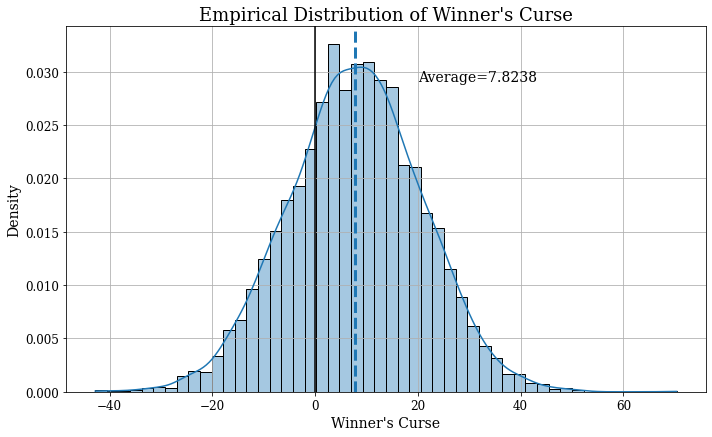

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', alpha=0.4)
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--', linewidth=3)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5)
ax.annotate(
    f"Average={wc_measures_dict['nc_wc_avg']:.4f}", 
    xy=(0.55, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Estimating Winner's Curse

In [13]:
dgp = MultipleSegments(**dgp_params) 
segment_arr, treatment_arr, outcome_arr = dgp.sample(data_params['sample_size'], seed=0)
targ_customers = dgp.sample_individuals(data_params['n_customers'], seed=0)

## Standard Bootstrap

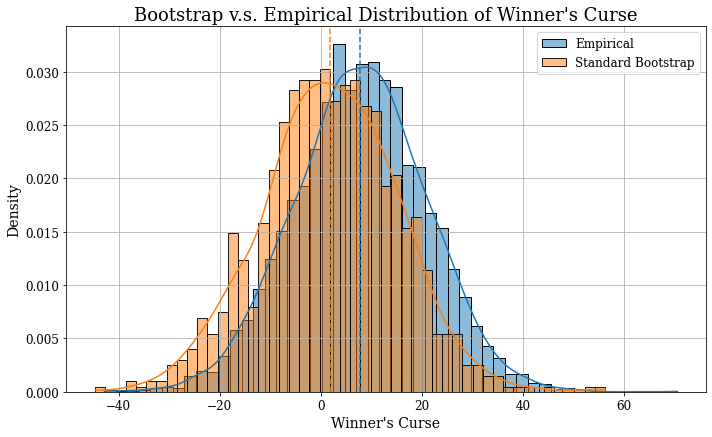

In [14]:
# generate bootstrap distribution
boot_wc_dstn_arr = tsms.get_wc_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers, 
    n_segments=dgp.n_segments, n_treatments=dgp.n_treatments,
    **operations_params, n_bootstraps=1000, n_jobs=-1, verbose=False, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap


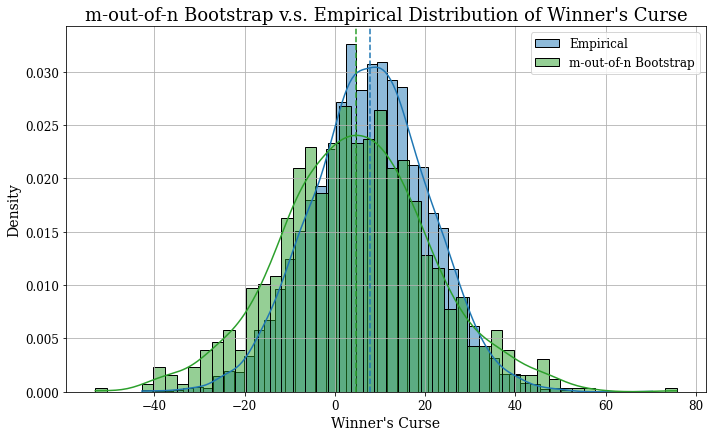

In [15]:
# generate bootstrap distribution
boot_wc_dstn_arr = tsms.get_wc_m_out_of_n_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers,
    n_segments=dgp.n_segments, n_treatments=dgp.n_treatments,
    **operations_params, power=0.9, n_bootstraps=1000, n_jobs=-1, verbose=False, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap


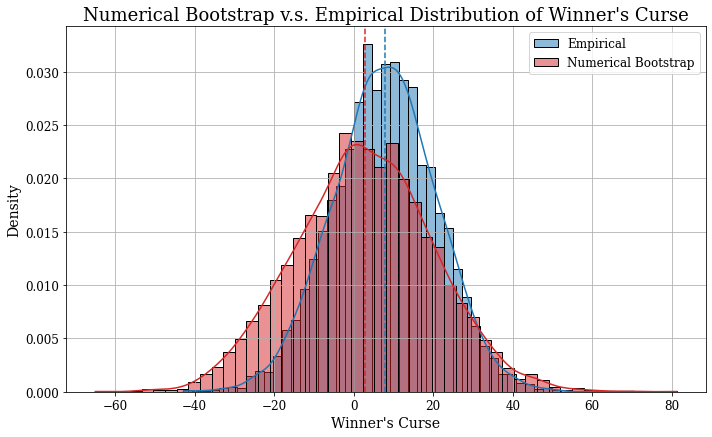

In [16]:
# generate bootstrap distribution
boot_wc_dstn_arr = tsms.get_wc_num_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers,
    n_segments=dgp.n_segments, n_treatments=dgp.n_treatments,
    **operations_params, power=-0.45, n_bootstraps=5000, n_jobs=-1, verbose=False, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Numerical Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [29]:
operations_params = {'budgets': [None, 30]}

# dgp params
dgp_params = {
    'base_te_arr': np.array([1, 1.1]), 'n_segments': 15,
    'response_type': 'continuous', 'noise_std': 1,
}

# data params
data_params = {'sample_size': 500, 'n_customers': 100}

# experiment params"
experiment_params = {'n_experiments': 1000, 'stats': 'mean'}

# estimators
estimators_dict = {
    'sample_splitting': {
        'estimator': tsms.sample_splitting_estimate, 
        'params': {}, 
        'display_name': 'Sample Splitting'
    }, 
    'cross_validation': {
        'estimator': tsms.cross_validation_estimate,
        'params': {'n_splits': 3},
        'display_name': 'Cross Validation'
    }, 
    'empirical_bayes': {
        'estimator': tsms.empirical_bayes_estimate, 
        'params': {'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes \nEfron 2011, JASA'
    }, 
    'normal_prior_bayes': {
        'estimator': tsms.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}, 
        'display_name': 'Normal Prior Bayes \nKessler 2024, Amazon'
    }, 
    'standard_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
            'n_jobs': 1,
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95, 'n_jobs': 1,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45, 'n_jobs': 1,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [30]:
result_records = tsms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = tsms.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   44.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  1.9min finished


In [31]:
wc_dict = {}
delta_tau = dgp_params['base_te_arr'][1] - dgp_params['base_te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            "Avg. True Policy Value": wc_measures_dict[f'{estimator}_val_true_avg'],
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 
print("Overestimated Profit Lift: ")
wc_df.round(2)

Overestimated Profit Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%),Avg. True Policy Value
No Correction,89.90,2.92,90.01,1.1
Sample Splitting,1.13,4.45,2.04,1.1
Cross Validation,-4.07,3.73,-2.32,1.1
"Empirical Bayes \nEfron 2011, JASA",-7.22,2.35,-9.07,1.1
"Normal Prior Bayes \nKessler 2024, Amazon",22.82,2.77,22.86,1.1
Standard Bootstrap,30.53,3.02,31.61,1.1
m-out-of-n Bootstrap,14.29,3.01,15.34,1.1
Numerical Bootstrap,8.97,3.07,9.86,1.1


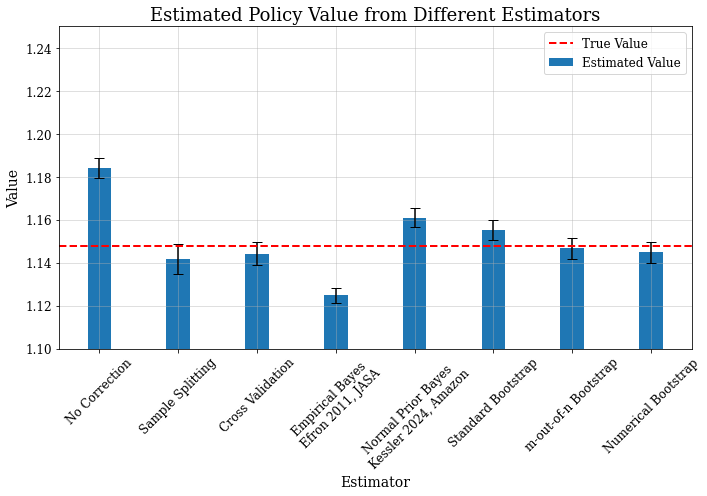

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

viz_estimators_list = ['nc', 'sample_splitting', 'cross_validation', 'empirical_bayes', 'normal_prior_bayes', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']
obj_val_list = [wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in viz_estimators_list]

ax.bar(
    x=np.arange(len(viz_estimators_list)), 
    height=obj_val_list, 
    yerr=[1.65 * wc_measures_dict[f'{estimator}_val_est_se'] for estimator in viz_estimators_list],
    capsize=5, color='C0', width=0.3
)

ax.axhline(wc_measures_dict['nc_val_true_avg'], color='red', linestyle='--', linewidth=2)

ax.set_title("Estimated Policy Value from Different Estimators", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(viz_estimators_list)))
ax.set_xticklabels(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in viz_estimators_list[1:]], rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

ax.set_ylim(1.1, 1.25)

ax.legend(['True Value', 'Estimated Value'], fontsize=legend_label_size)

ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

# Sensitivity Analysis

## Sample Size

In [60]:
for delta_tau in [0.05, 0.1, 0.5]:
    sample_sizes = np.array([500, 600, 700, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000])

    operations_params = {'budgets': [None, 30]}

    # dgp params
    dgp_params = {
        'base_te_arr': np.array([1, 1 + delta_tau]), 'n_segments': 5,
        'response_type': 'continuous', 'noise_std': 1,
    }

    # data params
    data_params = {'sample_size': np.nan, 'n_customers': 100}

    # experiment params"
    experiment_params = {'n_experiments': 5000, 'stats': 'mean'}

    # estimators
    estimators_dict = {
        'standard_bootstrap': {
            'estimator': tsms.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'standard',
                'n_jobs': 1,
            }, 
            'display_name': 'Standard Bootstrap'
        }, 
        'mn_bootstrap': {
            'estimator': tsms.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
                'power': 0.95, 'n_jobs': 1,
            }, 
            'display_name': 'm-out-of-n Bootstrap'
        }, 
        'num_bootstrap': {
            'estimator': tsms.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
                'power': - 0.45, 'n_jobs': 1,
            }, 
            'display_name': 'Numerical Bootstrap'
        }
    }

    result_dict = {sample_size: None for sample_size in sample_sizes}

    for sample_size in tqdm(sample_sizes):
        data_params['sample_size'] = int(sample_size)
        result_dict[sample_size] = tsms.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=False, n_jobs=-1
        )

    for key in result_dict.keys():
        result_dict[key] = tsms.calculate_winners_curse_measures(
            result_records=result_dict[key],
            estimators_dict=estimators_dict, data_params=data_params
        )

    # save results
    n_segments = dgp_params['n_segments']
    with open(f'results/tsms_sample_size_{delta_tau}_{n_segments}.pkl', 'wb') as f:
        pickle.dump(result_dict, f)

100%|██████████| 12/12 [39:36<00:00, 198.01s/it]


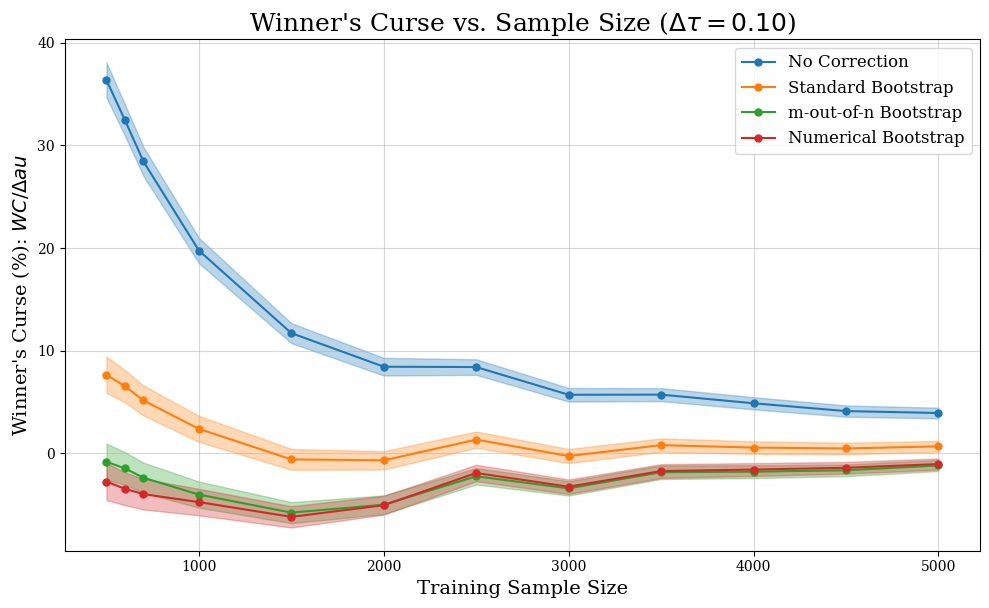

In [62]:
delta_tau = 0.10
n_segments = 5
estimators_viz_list = ['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']

with open(f'results/tsms_sample_size_{delta_tau}_{n_segments}.pkl', 'rb') as f:
    result_dict = pickle.load(f)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

width = 0.2

# plot winner's curse of no correction for each te_diff / noise_std pair
plot_list = [None] * len(estimators_viz_list)
for idx, estimator in enumerate(estimators_viz_list):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    wc_avg_arr = 100 * np.array([result_dict[key][f'{estimator}_wc_avg'] for key in result_dict.keys()]) / delta_tau
    wc_se_arr = 100 * np.array([result_dict[key][f'{estimator}_wc_se'] for key in result_dict.keys()]) / delta_tau
    # ax.bar(
    #     np.arange(len(wc_avg_arr)) + (idx - 1.5) * width, wc_avg_arr, yerr=wc_se_arr, capsize=5, color=f'C{idx}', alpha=0.75, width=width
    # )
    plot_list[idx], = ax.plot(sample_sizes, wc_avg_arr, 'o-', markersize=5, label=display_name, color=f'C{idx}')
    
    ax.fill_between(sample_sizes, wc_avg_arr - 1.96 * wc_se_arr, wc_avg_arr + 1.96 * wc_se_arr, color=f'C{idx}', alpha=0.3)

ax.set_title(r"Winner's Curse vs. Sample Size ($\Delta\tau={:.2f}$)".format(delta_tau), fontsize=title_size)
ax.set_xlabel('Training Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%): $WC/\Delta\tau$", fontsize=axis_label_size)
# ax.set_xticks(sample_sizes)
# ax.set_xticklabels(sample_sizes, rotation=45)
ax.grid(True, alpha=0.5)
ax.legend(handles=plot_list, loc='best', fontsize=legend_label_size)

plt.tight_layout()
plt.show()

# Bernoulli Response

In [41]:
operations_params = {'budgets': [None, 30]}

# dgp params
dgp_params = {
    'base_te_arr': np.array([0.1, 0.2]), 'n_segments': 5,
    'response_type': 'bernoulli', 'noise_std': 1,
}

# data params
data_params = {'sample_size': 500, 'n_customers': 100}

# experiment params"
experiment_params = {'n_experiments': 1000, 'stats': 'mean'}

# estimators
estimators_dict = {
    'sample_splitting': {
        'estimator': tsms.sample_splitting_estimate, 
        'params': {}, 
        'display_name': 'Sample Splitting'
    }, 
    'cross_validation': {
        'estimator': tsms.cross_validation_estimate,
        'params': {'n_splits': 5},
        'display_name': 'Cross Validation'
    }, 
    # 'empirical_bayes': {
    #     'estimator': tsms.empirical_bayes_estimate, 
    #     'params': {'dof': 3, 'bin_width': 0.2}, 
    #     'display_name': 'Empirical Bayes \nEfron 2011, JASA'
    # }, 
    'normal_prior_bayes': {
        'estimator': tsms.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}, 
        'display_name': 'Normal Prior Bayes \nKessler 2024, Amazon'
    }, 
    'standard_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
            'n_jobs': 1,
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.99, 'n_jobs': 1,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.49, 'n_jobs': 1,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [42]:
result_records = tsms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = tsms.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   35.9s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   48.2s finished


In [43]:
wc_dict = {}
delta_tau = dgp_params['base_te_arr'][1] - dgp_params['base_te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            "Avg. True Policy Value": wc_measures_dict[f'{estimator}_val_true_avg'],
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 
print("Overestimated Profit Lift: ")
wc_df.round(2)

Overestimated Profit Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%),Avg. True Policy Value
No Correction,6.15,1.19,6.34,0.26
Sample Splitting,-0.38,1.71,-0.37,0.26
Cross Validation,-0.97,1.35,0.08,0.26
"Normal Prior Bayes \nKessler 2024, Amazon",5.03,1.18,5.23,0.26
Standard Bootstrap,-0.91,1.23,-0.54,0.26
m-out-of-n Bootstrap,-1.26,1.23,-1.21,0.26
Numerical Bootstrap,-1.33,1.23,-1.21,0.26


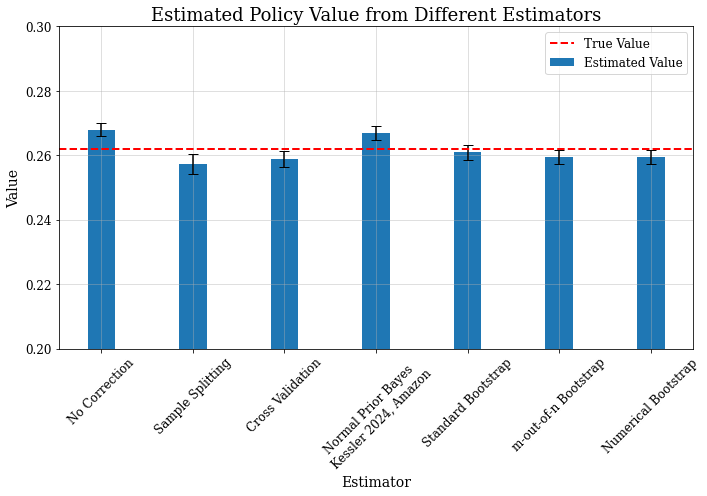

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

viz_estimators_list = ['nc', 'sample_splitting', 'cross_validation', 'normal_prior_bayes', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']
obj_val_list = [wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in viz_estimators_list]

ax.bar(
    x=np.arange(len(viz_estimators_list)), 
    height=obj_val_list, 
    yerr=[1.65 * wc_measures_dict[f'{estimator}_val_est_se'] for estimator in viz_estimators_list],
    capsize=5, color='C0', width=0.3
)

ax.axhline(wc_measures_dict['nc_val_true_avg'], color='red', linestyle='--', linewidth=2)

ax.set_title("Estimated Policy Value from Different Estimators", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(viz_estimators_list)))
ax.set_xticklabels(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in viz_estimators_list[1:]], rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

ax.set_ylim(0.2, 0.3)

ax.legend(['True Value', 'Estimated Value'], fontsize=legend_label_size)

ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

# Logit Model

In [56]:
operations_params = {'budgets': [None, 30]}

# dgp params
dgp_params = {
    'base_te_arr': np.array([0.1, 0.15]), 'n_segments': 5,
    'response_type': 'logit', 'noise_std': 1,
}

# data params
data_params = {'sample_size': 500, 'n_customers': 100}

# experiment params"
experiment_params = {'n_experiments': 1000, 'stats': 'mean'}

# estimators
estimators_dict = {
    'sample_splitting': {
        'estimator': tsms.sample_splitting_estimate, 
        'params': {}, 
        'display_name': 'Sample Splitting'
    }, 
    'cross_validation': {
        'estimator': tsms.cross_validation_estimate,
        'params': {'n_splits': 3},
        'display_name': 'Cross Validation'
    }, 
    # 'empirical_bayes': {
    #     'estimator': tsms.empirical_bayes_estimate, 
    #     'params': {'dof': 3, 'bin_width': 0.2}, 
    #     'display_name': 'Empirical Bayes \nEfron 2011, JASA'
    # }, 
    'normal_prior_bayes': {
        'estimator': tsms.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}, 
        'display_name': 'Normal Prior Bayes \nKessler 2024, Amazon'
    }, 
    'standard_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
            'n_jobs': 1,
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95, 'n_jobs': 1,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45, 'n_jobs': 1,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [57]:
result_records = tsms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = tsms.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   47.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  4.1min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  5.4min finished


In [58]:
wc_dict = {}
delta_tau = dgp_params['base_te_arr'][1] - dgp_params['base_te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            "Avg. True Policy Value": wc_measures_dict[f'{estimator}_val_true_avg'],
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 
print("Overestimated Profit Lift: ")
wc_df.round(2)

Overestimated Profit Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%),Avg. True Policy Value
No Correction,205.68,10.72,202.87,0.22
Sample Splitting,22.00,16.66,29.64,0.22
Cross Validation,27.50,14.99,6.60,0.22
"Normal Prior Bayes \nKessler 2024, Amazon",202.66,10.67,199.62,0.22
Standard Bootstrap,47.67,10.93,44.73,0.22
m-out-of-n Bootstrap,3.16,10.84,-3.50,0.22
Numerical Bootstrap,-9.87,11.10,-15.26,0.22
